<a href="https://colab.research.google.com/github/NadiiaDataAnalyst/Data-Driven-Process-Optimization-Project-2024-2025-/blob/main/Project_work_commercial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files


# LOADING

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/РЕЕСТР ОФОРМЛЕННЫХ  ДЕКЛАРАЦИЙ 2024.xlsx'

In [ ]:
df = pd.read_excel(path, sheet_name=None)
dfs = pd.concat(df.values(), ignore_index=True)
dfs

,№,Дата,Тип Деклараций,Номер Деклараций,Заказчик,Товар,Брокер,Номер Деклараций
0,1.0,2024-01-02 00:00:00,ЕК11АА,000021U1,ДСР,судно,Ирина,NaN
1,2.0,2024-01-02 00:00:00,ЕК10РР,017517U3,Долинський Елеватор,пшеница,Лиана,NaN
2,3.0,2024-01-03 00:00:00,ЕК10ДР,000048U4,Золотой Дракон,шрот,Надя,NaN
3,4.0,2024-01-03 00:00:00,ЕК10ДР,000054U2,Белогви,кукуруза,Надя,NaN
4,5.0,2024-01-03 00:00:00,ЕК10РР,017579U9,Китайпром,пшеница,Надя,NaN
...,...,...,...,...,...,...,...,...
736,9.0,2025-12-23 00:00:00,IM51ДЕ,NaN,Дунайсудоремонт,судно,Лиана,25UA500530004118U4
737,10.0,2025-12-25 00:00:00,IM40AA,NaN,Дунайсудоремонт,брухт,Надя,25UA500530004153U7
738,11.0,2025-12-26 00:00:00,ЕК10ДР,NaN,"ПП ""ГІДРОСЕНД""",шрот п.,Надя,25UA500530004160U4
739,12.0,2025-12-29 00:00:00,ЕК10РР,NaN,Промбудресурс КР,шлак,Надя,25UA500530004188U6


In [ ]:
print(dfs.columns.tolist())

['№ ', 'Дата', 'Тип Деклараций', 'Номер Деклараций ', 'Заказчик', 'Товар', 'Брокер', 'Номер Деклараций']


In [ ]:
pd.options.mode.chained_assignment = None

# CLEANUP

In [ ]:
dfs['ID of declaration'] = dfs['Номер Деклараций '].fillna(dfs['Номер Деклараций'])


In [ ]:
columns_to_drop = ['Номер Деклараций ', 'Номер Деклараций', '№ ']

In [ ]:
dfs.drop(columns=columns_to_drop, inplace=True)
dfs

,Дата,Тип Деклараций,Заказчик,Товар,Брокер,ID of declaration
0,2024-01-02 00:00:00,ЕК11АА,ДСР,судно,Ирина,000021U1
1,2024-01-02 00:00:00,ЕК10РР,Долинський Елеватор,пшеница,Лиана,017517U3
2,2024-01-03 00:00:00,ЕК10ДР,Золотой Дракон,шрот,Надя,000048U4
3,2024-01-03 00:00:00,ЕК10ДР,Белогви,кукуруза,Надя,000054U2
4,2024-01-03 00:00:00,ЕК10РР,Китайпром,пшеница,Надя,017579U9
...,...,...,...,...,...,...
736,2025-12-23 00:00:00,IM51ДЕ,Дунайсудоремонт,судно,Лиана,25UA500530004118U4
737,2025-12-25 00:00:00,IM40AA,Дунайсудоремонт,брухт,Надя,25UA500530004153U7
738,2025-12-26 00:00:00,ЕК10ДР,"ПП ""ГІДРОСЕНД""",шрот п.,Надя,25UA500530004160U4
739,2025-12-29 00:00:00,ЕК10РР,Промбудресурс КР,шлак,Надя,25UA500530004188U6


In [ ]:
dfs.rename(columns={
    'Дата': 'Date',
    'Тип Деклараций': 'Type of declaration',
    'Заказчик': 'Client',
    'Товар': 'Good',
    'Брокер': 'Broker'
}, inplace=True)
dfs

,Date,Type of declaration,Client,Good,Broker,ID of declaration
0,2024-01-02 00:00:00,ЕК11АА,ДСР,судно,Ирина,000021U1
1,2024-01-02 00:00:00,ЕК10РР,Долинський Елеватор,пшеница,Лиана,017517U3
2,2024-01-03 00:00:00,ЕК10ДР,Золотой Дракон,шрот,Надя,000048U4
3,2024-01-03 00:00:00,ЕК10ДР,Белогви,кукуруза,Надя,000054U2
4,2024-01-03 00:00:00,ЕК10РР,Китайпром,пшеница,Надя,017579U9
...,...,...,...,...,...,...
736,2025-12-23 00:00:00,IM51ДЕ,Дунайсудоремонт,судно,Лиана,25UA500530004118U4
737,2025-12-25 00:00:00,IM40AA,Дунайсудоремонт,брухт,Надя,25UA500530004153U7
738,2025-12-26 00:00:00,ЕК10ДР,"ПП ""ГІДРОСЕНД""",шрот п.,Надя,25UA500530004160U4
739,2025-12-29 00:00:00,ЕК10РР,Промбудресурс КР,шлак,Надя,25UA500530004188U6


##Filtration (without Prepaiment)

In [ ]:
df_clean = dfs[dfs['ID of declaration'] != 'ПРЕДОПЛАТА']
df_clean

,Date,Type of declaration,Client,Good,Broker,ID of declaration
0,2024-01-02 00:00:00,ЕК11АА,ДСР,судно,Ирина,000021U1
1,2024-01-02 00:00:00,ЕК10РР,Долинський Елеватор,пшеница,Лиана,017517U3
2,2024-01-03 00:00:00,ЕК10ДР,Золотой Дракон,шрот,Надя,000048U4
3,2024-01-03 00:00:00,ЕК10ДР,Белогви,кукуруза,Надя,000054U2
4,2024-01-03 00:00:00,ЕК10РР,Китайпром,пшеница,Надя,017579U9
...,...,...,...,...,...,...
736,2025-12-23 00:00:00,IM51ДЕ,Дунайсудоремонт,судно,Лиана,25UA500530004118U4
737,2025-12-25 00:00:00,IM40AA,Дунайсудоремонт,брухт,Надя,25UA500530004153U7
738,2025-12-26 00:00:00,ЕК10ДР,"ПП ""ГІДРОСЕНД""",шрот п.,Надя,25UA500530004160U4
739,2025-12-29 00:00:00,ЕК10РР,Промбудресурс КР,шлак,Надя,25UA500530004188U6


##Handling missing values

In [ ]:
df_clean.isnull().sum()

,0
Date,1
Type of declaration,0
Client,8
Good,2
Broker,12
ID of declaration,2


In [ ]:
df_clean['Date'] = df_clean.Date.fillna(method='ffill', axis=0)
df_clean['Client'] = df_clean.Client.fillna('not set', axis=0)
df_clean['Good'] = df_clean.Good.fillna('not set', axis=0)
df_clean['Broker'] = df_clean.Broker.fillna('not set', axis=0)
df_clean['ID of declaration'] = df_clean['ID of declaration'].fillna('not set', axis=0)



/tmp/ipykernel_1727/3415578639.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean['Date'] = df_clean.Date.fillna(method='ffill', axis=0)


In [ ]:
df_clean.isnull().sum()

,0
Date,0
Type of declaration,0
Client,0
Good,0
Broker,0
ID of declaration,0


##Checking for duplicates

In [ ]:
total_duplicates = df_clean.duplicated().sum()
total_duplicates

np.int64(0)

In [ ]:
duplicates_df = df_clean[df_clean.duplicated()]
print(duplicates_df)

Empty DataFrame
Columns: [Date, Type of declaration, Client, Good, Broker, ID of declaration]
Index: []


In [ ]:
df_clean = df_clean.drop_duplicates()




##Correction inconsistent data entries

In [ ]:
!pip install fuzzywuzzy python-Levenshtein charset-normalizer

In [ ]:
import numpy as np
import fuzzywuzzy
from fuzzywuzzy import process
import charset_normalizer


In [ ]:
df_clean['Type of declaration'] = df_clean['Type of declaration'].str[:2]

In [ ]:
df_clean['Good'] = df_clean['Good'].str.strip()
df_clean['Good'] = df_clean['Good'].str.lower()
df_clean['Good'] = df_clean['Good'].str.split().str[0]

In [ ]:
goods = df_clean['Good'].unique()
goods.sort()
goods

array(['mv', 'not', 'боксити', 'брухт', 'горох', 'добрива', 'добриво',
       'експорт', 'ел.апаратура', 'електрична', 'електро', 'запчастини',
       'конвейер', 'конвейери', 'контейнери,', 'кукуруда', 'кукурудза',
       'кукуруза', 'макуха', 'масло', 'металлолом', 'нітрат', 'плавучий',
       'прес', 'пшеница', 'пшениця', 'пщениця', 'рапс', 'ріпак',
       'семечка', 'соя', 'судно', 'установка', 'фарба', 'цементний',
       'шлак', 'шрот', 'щебень', 'щебінь', 'экспорт', 'ячмень', 'ячмінь'],
      dtype=object)

In [ ]:
matches = fuzzywuzzy.process.extract("добриво", goods, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)
matches

[('добриво', 100),
 ('добрива', 86),
 ('горох', 50),
 ('конвейери', 38),
 ('шрот', 36),
 ('контейнери,', 35),
 ('брухт', 33),
 ('судно', 33),
 ('боксити', 29),
 ('експорт', 29)]

In [ ]:
def replace_matches_in_column(df, column, string_to_match, min_ratio = 82):
    # get a list of unique strings
    strings = df[column].unique()

    # get the top 10 closest matches to our input string
    matches = fuzzywuzzy.process.extract(string_to_match, strings,
                                         limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)

    # only get matches with a ratio > 90
    close_matches = [matches[0] for matches in matches if matches[1] >= min_ratio]

    # get the rows of all the close matches in our dataframe
    rows_with_matches = df[column].isin(close_matches)

    # replace all rows with close matches with the input matches
    df.loc[rows_with_matches, column] = string_to_match

    # let us know the function's done
    print("All done!")


In [ ]:
replace_matches_in_column(df=df_clean, column='Good', string_to_match="добриво")

All done!


In [ ]:
matches = fuzzywuzzy.process.extract("конвейер", goods, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)
replace_matches_in_column(df=df_clean, column='Good', string_to_match="конвейер")

All done!


In [ ]:
matches = fuzzywuzzy.process.extract("кукурудза", goods, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)
replace_matches_in_column(df=df_clean, column='Good', string_to_match="кукурудза")

All done!


In [ ]:
matches = fuzzywuzzy.process.extract("пшениця", goods, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)
replace_matches_in_column(df=df_clean, column='Good', string_to_match="пшениця")

All done!


In [ ]:
matches = fuzzywuzzy.process.extract("ячмінь", goods, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)
replace_matches_in_column(df=df_clean, column='Good', string_to_match="ячмінь")

All done!


In [ ]:
matches = fuzzywuzzy.process.extract("щебінь", goods, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)
replace_matches_in_column(df=df_clean, column='Good', string_to_match="щебінь")

All done!


In [ ]:
goods = df_clean['Good'].astype(str).unique()
goods.sort()
goods

array(['mv', 'not', 'боксити', 'брухт', 'горох', 'добриво', 'експорт',
       'ел.апаратура', 'електрична', 'електро', 'запчастини', 'конвейер',
       'контейнери,', 'кукурудза', 'макуха', 'масло', 'металлолом',
       'нітрат', 'плавучий', 'прес', 'пшениця', 'рапс', 'ріпак',
       'семечка', 'соя', 'судно', 'установка', 'фарба', 'цементний',
       'шлак', 'шрот', 'щебінь', 'экспорт', 'ячмінь'], dtype=object)

In [ ]:
df_clean['Good'] = df_clean['Good'].replace({
'масло':'олія',
'металлолом': 'брухт',
'електрична': 'ел.апаратура',
'електро': 'ел.апаратура',
'рапс': 'ріпак',
'm/v': 'судно',
'mv': 'судно',
'экспорт': 'експорт'
}, regex=False)

In [ ]:
goods = df_clean['Good'].astype(str).unique()
goods.sort()
goods

array(['not', 'боксити', 'брухт', 'горох', 'добриво', 'експорт',
       'ел.апаратура', 'запчастини', 'конвейер', 'контейнери,',
       'кукурудза', 'макуха', 'нітрат', 'олія', 'плавучий', 'прес',
       'пшениця', 'ріпак', 'семечка', 'соя', 'судно', 'установка',
       'фарба', 'цементний', 'шлак', 'шрот', 'щебінь', 'ячмінь'],
      dtype=object)

In [ ]:
df_clean['Client'] = df_clean['Client'].str.strip()



In [ ]:
clients = df_clean['Client'].astype(str).unique()
clients.sort()
clients

array(['BC Tanker LTD', 'KIA ORA', 'PASSAGE', 'Valship', 'Vimeksim',
       'not set', 'Інгулземінвест', 'Інгулметінвест', 'Ісіда',
       'Агро Фонд', 'Агролайт Групп', 'Агропроінвест 08',
       'Агрофірма Ісіда', 'Агрохолдінг Дар', 'Атлас Трейдинг',
       'Атлас Трейдінг', 'БГС РЕЙЛ', 'БГС-Рейл', 'Белогви', 'Білагро',
       'ВК "Золотий Дракон"', 'Вимексим/Лан-Оіл', 'Волинь Лом',
       'Волметсервіс', 'ГАРНА ЛОГІСТИКА', 'ГАРНА ТРЕЙДИНГ УКРАЇНА',
       'Галактика', 'Гарна Логистика', 'Гарна Трейдінг',
       'Гарна Трейдінг Укр.', 'Гарна Трейдінг Україна',
       'ДОЛИНСЬКИЙ ЕЛЕВАТОР', 'ДСР', 'ДСР (аг.Лаурус)', 'ДСС',
       'Деренківець', 'Дилекс Трейд', 'Док-Сервис', 'Долинський Елеватор',
       'Долинський елеватор', 'Долинські Лани', 'Дрим Агро Експорт',
       'Дрім Агро Експорт', 'Дунайсудноремонт', 'Дунайсудоремонт',
       'Ділекс Трейд', 'ЕКСИМ-АГРО', 'Ексим Агро', 'Ексим-Агро',
       'Ексім-Агро', 'Елайн Логістик', 'Елайн-Логістік',
       'Еликсир Украина', 'Еліксир 

In [ ]:
df_clean['Client'] = df_clean['Client'].replace({
'ДСР':'Дунайсудноремонт',
'Дунайсудоремонт':'Дунайсудноремонт',
'ДСС': 'Дунайсудносервіс',
'ТОВ "Західдорбуд"': 'Західдорбуд',
'Захиддорбуд': 'Західдорбуд',
'Еликсир Украина': 'Еліксир Україна',
'Дрим Агро Експорт': 'Дрім Агро Експорт',
'ПОА Україна':'ПОА "Україна"',
'ПА Ерчики': 'ПА "Ерчики"',
'ТД АОІЛ': 'ТОВ "ТД АОІЛ"',
'ТОВ ТД АОИЛ': 'ТОВ "ТД АОІЛ"',
'Гарна Трейдінг Укр.': 'Гарна Трейдінг Україна',
'ГАРНА ТРЕЙДИНГ УКРАЇНА': 'Гарна Трейдінг Україна',
'ГАРНА ЛОГІСТИКА': 'Гарна Логістика',
'Гарна Логистика': 'Гарна Логістика',
'Гарна Трейдінг': 'Гарна Трейдінг Україна',
'Фермерське господарство «Подолянка»': 'Подолянка',
'Фермерське господарство "ПОДОЛЯНКА"': 'Подолянка',
'БГС РЕЙЛ': 'ТОВ "БГС РЕЙЛ"',
'Дилекс Трейд': 'Ділекс Трейд',
'Ексим-Агро': 'Ексим Агро',
'ПП "КАРАКЛІЯ"': 'Караклия',
'ПП "Караклія"': 'Караклия',
'ТОВ «ПРОМБУДРЕСУРС КР»': 'Промбудресурс КР',
'ТОВ "ПРОМБУДРЕСУРС КР"':'Промбудресурс КР',
'ТОВ ЕКСИМ-АГРО': 'Ексим Агро',
'Ексім-Агро': 'Ексим Агро',
'ЕКСИМ-АГРО': 'Ексим Агро',
'Елайн Логістик': 'Елайн-Логістік',
'Золотий дракон':'Золотий Дракон',
'Золотой Дракон': 'Золотий Дракон',
'ТОВ "ФРАНКО-АГРОТРЕЙД"': 'Франко-Агротрейд',
'ТОВ "Франко-Агротрейд"': 'Франко-Агротрейд',
'ТОВ Солео': 'Солео',
'Вимексим': 'ПП "Лан-Оіл Трейд"',
'ТОВ Солео': 'Солео',
'ДОЛИНСЬКИЙ ЕЛЕВАТОР':'Долинський Елеватор',
'ТОВ "Пріоритет-В"':'Пріоритет-В',
'Ісіда': 'Агрофірма Ісіда',
'ТОВ Білагро': 'Білагро',
'Вимексим/Лан-Оіл': 'ПП "Лан-Оіл Трейд"',
'ТОВ МАНАД': 'ТОВ "МАНАД"',
'ПСП "Ексім-Агро"': 'Ексим Агро',
'ТОВ АФ "ЛАН-СК"': 'ТОВ АФ "Лан-СК"',
'Хлібодар': 'ТОВ "Хлібодар"',
'ДСР (аг.Лаурус)': 'Дунайсудноремонт',
'Фалькон-Агро': 'ТОВ Фалькон-Агро',
'Фалькон Агро': 'ТОВ Фалькон-Агро',
'Караклія': 'Караклия',
'ЗОЛОТОЙ ДРАКОН': 'Золотий дракон',
'ВК "Золотий Дракон"': 'Золотий дракон',
'Українсько-американське спільне підприємство у формі товариства з обмеженою відповідальністю «КАІС»': 'УАСП ТОВ "КАІС"',
'ПП "Лан-Оіл Трейд"/Вимексим': 'ПП "Лан-Оіл Трейд"',
'Інгулземінвест': 'Інгулметінвест',
'Долинський елеватор': 'Долинський Елеватор',
'Атлас Трейдинг': 'Атлас Трейдінг',
'ТОВ "СОФ МАРІН"': 'Соф Марин',
'ч/з Соф Марін': 'Соф Марин',
'Соф Марин-С': 'Соф Марин',
'оплатили Е.И. расч.сч.': 'Соф Марин',
'ч/з Соф Марин': 'Соф Марин',
'Соф Марин С': 'Соф Марин'
}, regex=False)

In [ ]:
clients = df_clean['Client'].astype(str).unique()
clients.sort()
clients

array(['BC Tanker LTD', 'KIA ORA', 'PASSAGE', 'Valship', 'Vimeksim',
       'not set', 'Інгулметінвест', 'Агро Фонд', 'Агролайт Групп',
       'Агропроінвест 08', 'Агрофірма Ісіда', 'Агрохолдінг Дар',
       'Атлас Трейдінг', 'БГС-Рейл', 'Белогви', 'Білагро', 'Волинь Лом',
       'Волметсервіс', 'Галактика', 'Гарна Логістика',
       'Гарна Трейдінг Україна', 'Деренківець', 'Док-Сервис',
       'Долинський Елеватор', 'Долинські Лани', 'Дрім Агро Експорт',
       'Дунайсудноремонт', 'Дунайсудносервіс', 'Ділекс Трейд',
       'Ексим Агро', 'Елайн-Логістік', 'Еліксир Україна', 'Західдорбуд',
       'Зернозбуд', 'Злата-Трейд', 'Золотий Дракон', 'Золотий дракон',
       'КОРПОРАЦІЯ "УКРАГРОТЕХ"', 'Караклия', 'Китайпром', 'Крам Агро',
       'Краншип', 'Красненський КХП', 'Логос Транс Плюс', 'МПП "Обрій"',
       'Новаагро', 'Новатек (Елайн)', 'Обрій', 'ПА "Ерчики"',
       'ПОА "Україна"', 'ПП "ГІДРОСЕНД"', 'ПП "Лан-Оіл Трейд"',
       'Павлоградзернопродукт', 'Паливний Альянс Прозоре', 'По

In [ ]:
df_clean['Broker'] = df_clean['Broker'].str.strip()
brokers = df_clean['Broker'].unique()
brokers

array(['Ирина', 'Лиана', 'Надя', 'Ира', 'Іра', 'Ліана', 'not set'],
      dtype=object)

In [ ]:
dfs['Broker'] = dfs['Broker'].replace({
'Ира':'Іра',
'Ирина': 'Іра',
'Лиана': 'Ліана'})

##Parcing Dates

In [ ]:
df_clean.dtypes

,0
Date,object
Type of declaration,object
Client,object
Good,object
Broker,object
ID of declaration,object


In [ ]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True, errors='coerce')


In [ ]:
df_clean['Year'] = df_clean['Date'].dt.year

In [ ]:
df_clean['Month number'] = df_clean['Date'].dt.month

In [ ]:
df_clean['Month name'] = df_clean['Date'].dt.month_name()

In [ ]:
months_ua = {
    'January': 'Січень', 'February': 'Лютий', 'March': 'Березень',
    'April': 'Квітень', 'May': 'Травень', 'June': 'Червень',
    'July': 'Липень', 'August': 'Серпень', 'September': 'Вересень',
    'October': 'Жовтень', 'November': 'Листопад', 'December': 'Грудень'
}

# Заміна
df_clean['Month name'] = df_clean['Month name'].map(months_ua)

In [ ]:
df_clean['Week Number'] = df_clean['Date'].apply(lambda x: int(x.strftime('%W')) if pd.notna(x) else None)

In [ ]:
df_clean['Quarter'] = df_clean['Date'].dt.quarter

In [ ]:
df_clean

,Date,Type of declaration,Client,Good,Broker,ID of declaration,Year,Month number,Month name,Week Number,Quarter,WeekDay
0,2024-01-02,ЕК,Дунайсудноремонт,судно,Ирина,000021U1,2024,1,Січень,1,1,1
1,2024-01-02,ЕК,Долинський Елеватор,пшениця,Лиана,017517U3,2024,1,Січень,1,1,1
2,2024-01-03,ЕК,Золотий Дракон,шрот,Надя,000048U4,2024,1,Січень,1,1,2
3,2024-01-03,ЕК,Белогви,кукурудза,Надя,000054U2,2024,1,Січень,1,1,2
4,2024-01-03,ЕК,Китайпром,пшениця,Надя,017579U9,2024,1,Січень,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...
715,2025-12-23,IM,Дунайсудноремонт,судно,Лиана,25UA500530004118U4,2025,12,Грудень,51,4,1
716,2025-12-25,IM,Дунайсудноремонт,брухт,Надя,25UA500530004153U7,2025,12,Грудень,51,4,3
717,2025-12-26,ЕК,"ПП ""ГІДРОСЕНД""",шрот,Надя,25UA500530004160U4,2025,12,Грудень,51,4,4
718,2025-12-29,ЕК,Промбудресурс КР,шлак,Надя,25UA500530004188U6,2025,12,Грудень,52,4,0


# EXPORT

In [ ]:
df_clean.to_excel("reestr_of_decl5.xlsx", index=False)

# SEASONALITY

In [ ]:
df_clean = df_clean.set_index("Date")
df_clean = df_clean.sort_index()


In [ ]:
daily_count_id = df_clean['ID of declaration'].resample("D").count().reset_index()
daily_count_id

,Date,ID of declaration
0,2024-01-02,2
1,2024-01-03,4
2,2024-01-04,3
3,2024-01-05,1
4,2024-01-06,2
...,...,...
724,2025-12-26,1
725,2025-12-27,0
726,2025-12-28,0
727,2025-12-29,1


In [ ]:
import plotly.express as px
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.seasonal import STL

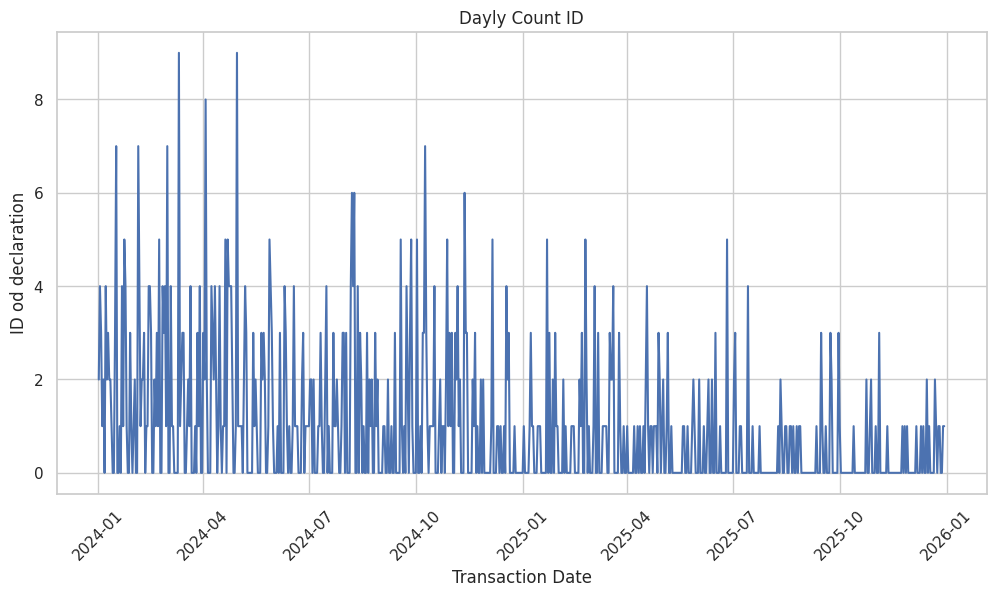

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=daily_count_id ,
    x='Date',
    y='ID of declaration'
)

plt.title('Dayly Count ID')
plt.xlabel('Transaction Date')
plt.ylabel('ID od declaration')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
quarter_count_id = df_clean.resample('Q')['ID of declaration'].count().reset_index()
quarter_count_id

/tmp/ipykernel_1727/3772103842.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_count_id = df_clean.resample('Q')['ID of declaration'].count().reset_index()


,Date,ID of declaration
0,2024-03-31,163
1,2024-06-30,145
2,2024-09-30,112
3,2024-12-31,106
4,2025-03-31,73
5,2025-06-30,54
6,2025-09-30,39
7,2025-12-31,28


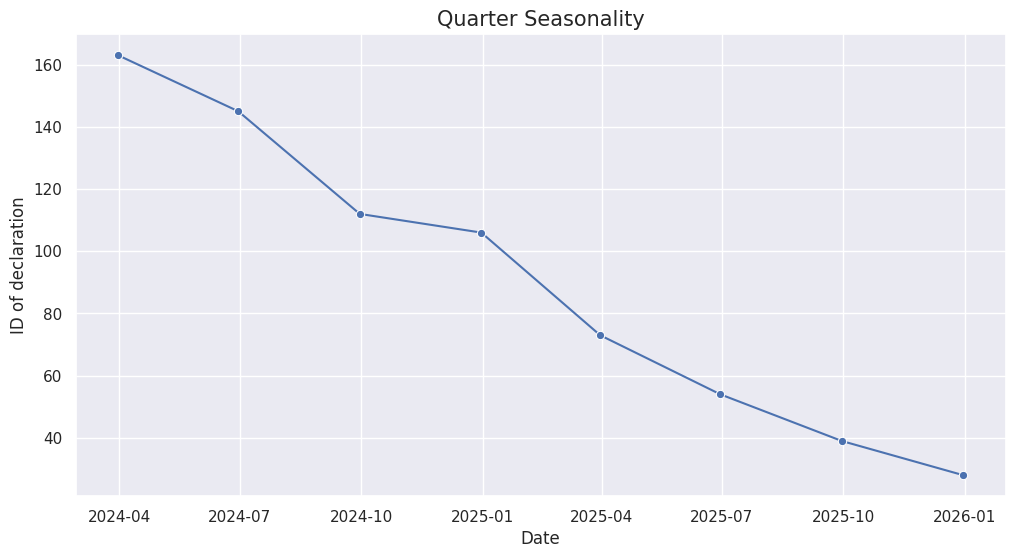

In [ ]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=quarter_count_id,
    x='Date',
    y='ID of declaration',
    marker='o'
)
plt.title('Quarter Seasonality', fontsize=15)
plt.xlabel('Date')
plt.ylabel('ID of declaration')
plt.show()

In [ ]:
df_clean = df_clean.reset_index()


In [ ]:
df_clean['WeekDay'] = df_clean['Date'].dt.weekday
df_clean

,Date,Type of declaration,Client,Good,Broker,ID of declaration,Year,Month number,Month name,Week Number,Quarter,WeekDay
0,2024-01-02,ЕК,Дунайсудноремонт,судно,Ирина,000021U1,2024,1,Січень,1,1,1
1,2024-01-02,ЕК,Долинський Елеватор,пшениця,Лиана,017517U3,2024,1,Січень,1,1,1
2,2024-01-03,ЕК,Золотий Дракон,шрот,Надя,000048U4,2024,1,Січень,1,1,2
3,2024-01-03,ЕК,Белогви,кукурудза,Надя,000054U2,2024,1,Січень,1,1,2
4,2024-01-03,ЕК,Китайпром,пшениця,Надя,017579U9,2024,1,Січень,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...
715,2025-12-23,IM,Дунайсудноремонт,судно,Лиана,25UA500530004118U4,2025,12,Грудень,51,4,1
716,2025-12-25,IM,Дунайсудноремонт,брухт,Надя,25UA500530004153U7,2025,12,Грудень,51,4,3
717,2025-12-26,ЕК,"ПП ""ГІДРОСЕНД""",шрот,Надя,25UA500530004160U4,2025,12,Грудень,51,4,4
718,2025-12-29,ЕК,Промбудресурс КР,шлак,Надя,25UA500530004188U6,2025,12,Грудень,52,4,0


In [ ]:
daily_counts = df_clean.groupby(['Date', 'WeekDay'])['ID of declaration'].count().reset_index()
weekday_mean_id = daily_counts.groupby('WeekDay')["ID of declaration"].mean().reset_index()
weekday_mean_id

,WeekDay,ID of declaration
0,0,2.490909
1,1,2.183099
2,2,2.524590
3,3,2.016667
4,4,1.983051
5,5,1.409091
6,6,1.250000


In [ ]:
days_map = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday',
    3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}

In [ ]:
weekday_mean_id['WeekDay'] = weekday_mean_id['WeekDay'].map(days_map)
weekday_mean_id

,WeekDay,ID of declaration
0,Monday,2.490909
1,Tuesday,2.183099
2,Wednesday,2.524590
3,Thursday,2.016667
4,Friday,1.983051
5,Saturday,1.409091
6,Sunday,1.250000


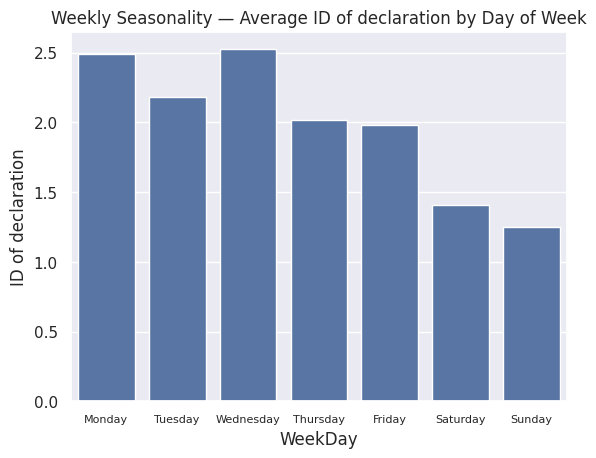

In [ ]:
sns.barplot(
    data=weekday_mean_id,
    x="WeekDay",
    y="ID of declaration",
    errorbar=None
)

plt.title("Weekly Seasonality — Average ID of declaration by Day of Week")
plt.xlabel("WeekDay")
plt.ylabel("ID of declaration")
plt.xticks(fontsize=8)
plt.show()

In [ ]:
weekday_year_count_id = df_clean.groupby(['WeekDay', 'Year'])['ID of declaration'].count().reset_index()
weekday_year_count_id

,WeekDay,Year,ID of declaration
0,0,2024,94
1,0,2025,43
2,1,2024,111
3,1,2025,44
4,2,2024,121
5,2,2025,33
6,3,2024,91
7,3,2025,30
8,4,2024,81
9,4,2025,36


In [ ]:
weekday_year_count_id['WeekDay'] = weekday_year_count_id['WeekDay'].map(days_map)
weekday_year_count_id

,WeekDay,Year,ID of declaration
0,Monday,2024,94
1,Monday,2025,43
2,Tuesday,2024,111
3,Tuesday,2025,44
4,Wednesday,2024,121
5,Wednesday,2025,33
6,Thursday,2024,91
7,Thursday,2025,30
8,Friday,2024,81
9,Friday,2025,36


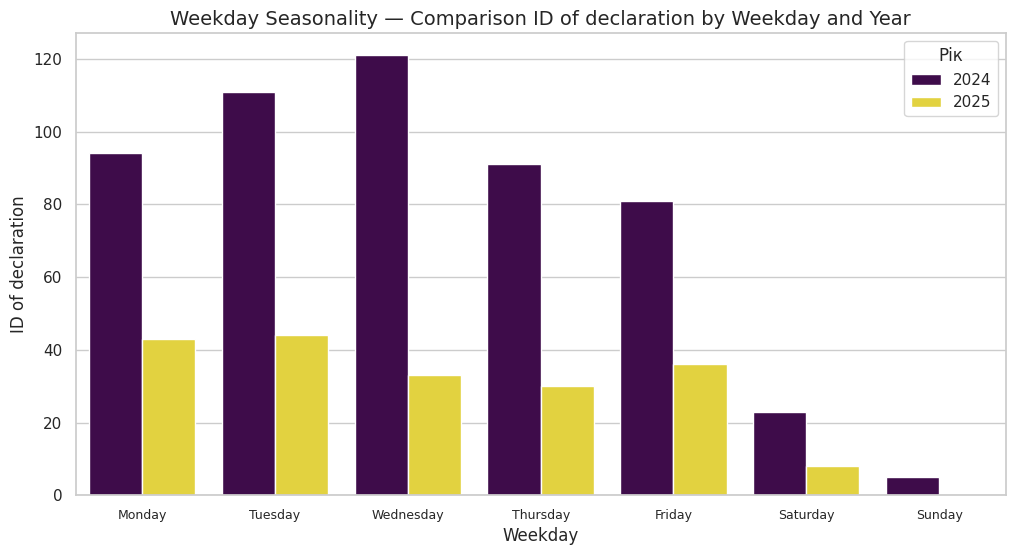

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=weekday_year_count_id,
    x="WeekDay",
    y="ID of declaration",
    hue="Year",
    palette="viridis"
)

plt.title("Weekday Seasonality — Comparison ID of declaration by Weekday and Year", fontsize=14)
plt.xlabel("Weekday", fontsize=12)
plt.ylabel("ID of declaration", fontsize=12)
plt.legend(title='Рік')
plt.xticks(fontsize=9)
plt.show()

In [ ]:
monthly_count_id = df_clean.groupby(['Year','Month name'])["ID of declaration"].count().sort_values(ascending=False).reset_index()
monthly_mean_id = monthly_count_id.groupby('Month name')["ID of declaration"].mean().sort_values(ascending=False).reset_index()
monthly_mean_id

,Month name,ID of declaration
0,Квітень,47.0
1,Січень,40.5
2,Лютий,39.5
3,Березень,38.0
4,Травень,29.5
5,Серпень,29.5
6,Жовтень,27.5
7,Липень,24.0
8,Листопад,23.0
9,Червень,23.0


# CONCLUSION ON SEASONALITY

Спираючись на представлені графіки та таблиці, можна зробити комплексний аналіз сезонності кількості декларацій у відділі.

Ось основні висновки, розподілені за рівнями аналітики:

1. Глобальний тренд та квартальна сезонність (Quarter Seasonality)
Падіння обсягів: На графіку Quarter Seasonality чітко видно сильний спадний тренд. Починаючи з другого кварталу 2024 року (2024-04), кількість декларацій стабільно та стрімко зменшується — зі 160+ до менш ніж 40 на початок 2026 року.

Висновок: Відбувається загальне скорочення навантаження або обсягів роботи відділу в часі. Через це класичну річну сезонність виявити складно — лінійний тренд «задавлює» сезонні коливання.

2. Щомісячна активність (Monthly)
Якщо проаналізувати зведену таблицю monthly_count_id (агреговану за весь період):

Пікові місяці: Найбільша активність припадає на квітень (47 декларацій), а також на зимово-весняний період — січень (40,5), лютий (39) та березень (38).

Спад: Найнижчий показник зафіксовано у грудні (16,5). Літо та осінь тримаються на середньому рівні (22–30 декларацій).

3. Тижнева сезонність (Weekly / Weekday Seasonality)
Тут спостерігається найчіткіша та найстабільніша сезонність:

Робочі дні (Пік): Основний обсяг роботи виконується у понеділок та середу. Вівторок, четвер та п'ятниця теж завантажені, але трохи менше.

Вихідні (Спад): У суботу активність різко падає, а в неділю практично повністю відсутня (поодинокі декларації).

4. Порівняння тижневої активності за роками (2024 vs 2025)
Підтвердження тренду: Графік порівняння років наочно ілюструє падіння обсягів: у 2025 році (жовті стовпчики) кількість декларацій в усі дні тижня впала більш ніж удвічі порівняно з 2024 роком (фіолетові стовпчики).

Зміщення пікових днів: Цікаво, що у 2024 році найзавантаженішим днем була середа, а у 2025 році пік змістився на понеділок та вівторок. Проте загальна логіка «працюємо в будні, відпочиваємо у вихідні» залишилася незмінною.

# EXECUTIVE SUMMARY

Головним фактором, що визначає вигляд графіків, є не сезонність, а сильний спадний тренд — загальна кількість оформлених декларацій у відділі скоротилася в кілька разів за аналізований період (2024–2025 рр.). У 2025 році оформлено 190 декларації проти 521 у 2024-му — падіння на 65%. Середньомісячний показник впав з 43 до 16 декларацій. Західдорбуд (196 декл.), Промбудресурс КР (105 декл.) та Дунайсудноремонт (124 декл.) разом дають ~60% усіх декларацій. Втрата хоча б одного критично вдарить по відділу. В 2025 відділ втратив клієнта Західдорбуд. Відділ спеціалізується на експортних операціях — переважно зернові (455 експортних декларацій в 2024, 151 експортних декл. в 2025)

# RECOMMENDATIONS

1. Диверсифікувати клієнтську базу
Жоден клієнт не повинен давати >15% обсягу. Зараз Західдорбуд — 27,5%. Активно залучати нових клієнтів.
2. Планувати відпустки в низький сезон
Червень–липень, грудень — традиційний спад. Брати відпустки тоді, а не в квітні, коли пік навантаження
3. Експортні декларації складають 85% оформлень. Рекомендовано розширити процеси декларування, впроваджуючи комплексне оформлення всіх митних режимів (імпорт, експорт, транзит).
4. Ввести місячний KPI для брокерів. Щомісяця звіряти факт з планом, не чекати кінця року.
5. Найняти нового брокера замість Іри
 Без нового співробітника ріст неможливий.



